In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [6]:
import os
print(os.getcwd())

C:\SPIT\Coding\PROJECTS\aircraft_predictive_maintainance\notebooks


In [7]:
os.listdir()

['.ipynb_checkpoints', '01_EDA.ipynb']

In [8]:
train_df = pd.read_csv(
    "../data/train_FD001.txt",
    sep=r"\s+",
    header=None
)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [9]:
train_df.shape

(20631, 26)

In [10]:
column_names = (
    ["engine_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_df.columns = column_names

train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [12]:
train_df.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [13]:
print("Number of rows:", train_df.shape[0])
print("Number of columns:", train_df.shape[1])
print("Number of engines:", train_df["engine_id"].nunique())

Number of rows: 20631
Number of columns: 26
Number of engines: 100


In [14]:
engine_life = train_df.groupby("engine_id")["cycle"].max()

engine_life.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

In [16]:
train_df.tail()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,21.61,550.79,2388.26,9061.48,1.3,48.20,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [17]:
#Variance Analysis
train_df.nunique().sort_values()

sensor_1           1
op_setting_3       1
sensor_10          1
sensor_5           1
sensor_19          1
sensor_16          1
sensor_18          1
sensor_6           2
sensor_17         13
op_setting_2      13
sensor_8          53
sensor_13         56
engine_id        100
sensor_20        120
op_setting_1     158
sensor_11        159
sensor_2         310
cycle            362
sensor_12        427
sensor_7         513
sensor_15       1918
sensor_3        3012
sensor_4        4051
sensor_21       4745
sensor_14       6078
sensor_9        6403
dtype: int64

In [18]:
train_df.nunique().sort_values().head(15)

sensor_1          1
op_setting_3      1
sensor_10         1
sensor_5          1
sensor_19         1
sensor_16         1
sensor_18         1
sensor_6          2
sensor_17        13
op_setting_2     13
sensor_8         53
sensor_13        56
engine_id       100
sensor_20       120
op_setting_1    158
dtype: int64

In [19]:
constant_features = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19",
    "op_setting_3"
]

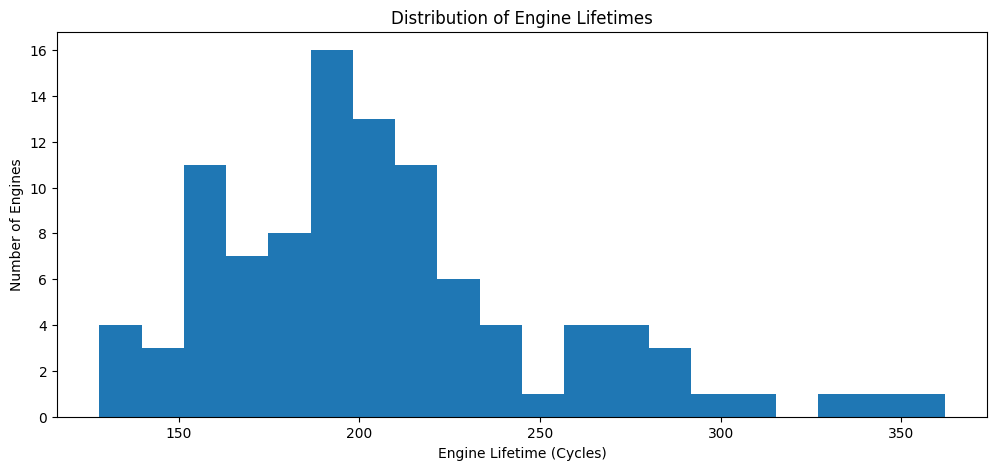

In [20]:
#Find and visualize engine life
engine_life = train_df.groupby("engine_id")["cycle"].max()

plt.figure(figsize=(12,5))
plt.hist(engine_life, bins=20)

plt.xlabel("Engine Lifetime (Cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")

plt.show()

In [21]:
engine_life.sort_values().head()

engine_id
39    128
91    135
70    137
57    137
24    147
Name: cycle, dtype: int64

In [22]:
engine_life.sort_values().tail()

engine_id
83    293
67    313
96    336
92    341
69    362
Name: cycle, dtype: int64

In [29]:
#Ranking sensors by variablitly ie Which sensors never move, Which sensors move a lot
sensor_cols = [col for col in train_df.columns if "sensor" in col]

train_df[sensor_cols].std().sort_values()

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.387812e-17
sensor_5     1.776400e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

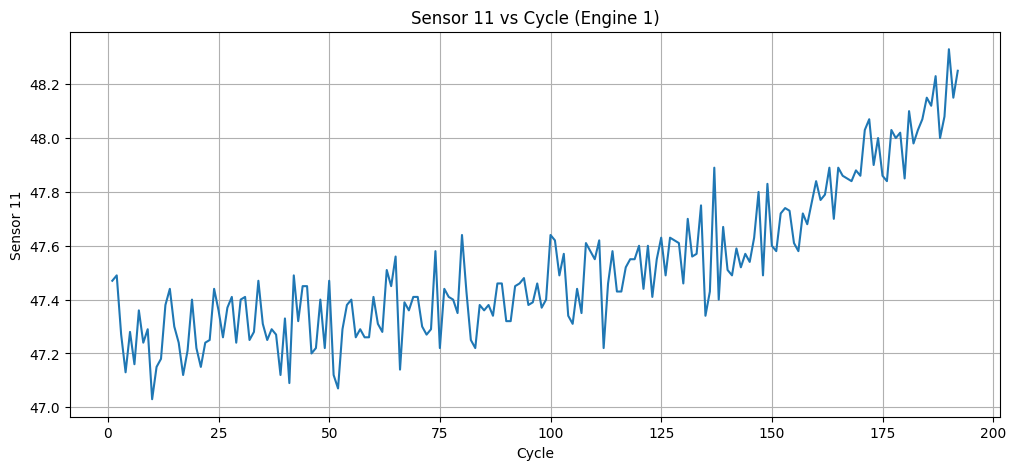

In [23]:
#see how sensor values change as engines age
engine_1 = train_df[train_df["engine_id"] == 1]

plt.figure(figsize=(12,5))
plt.plot(engine_1["cycle"], engine_1["sensor_11"])

plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 vs Cycle (Engine 1)")
plt.grid(True)

plt.show()

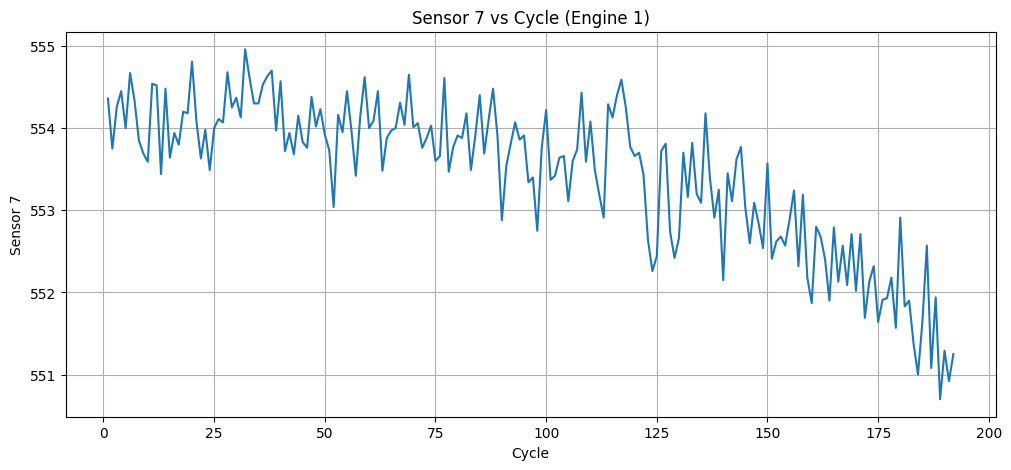

In [24]:
#see how sensor values change as engines age
engine_1 = train_df[train_df["engine_id"] == 1]

plt.figure(figsize=(12,5))
plt.plot(engine_1["cycle"], engine_1["sensor_7"])

plt.xlabel("Cycle")
plt.ylabel("Sensor 7")
plt.title("Sensor 7 vs Cycle (Engine 1)")
plt.grid(True)

plt.show()

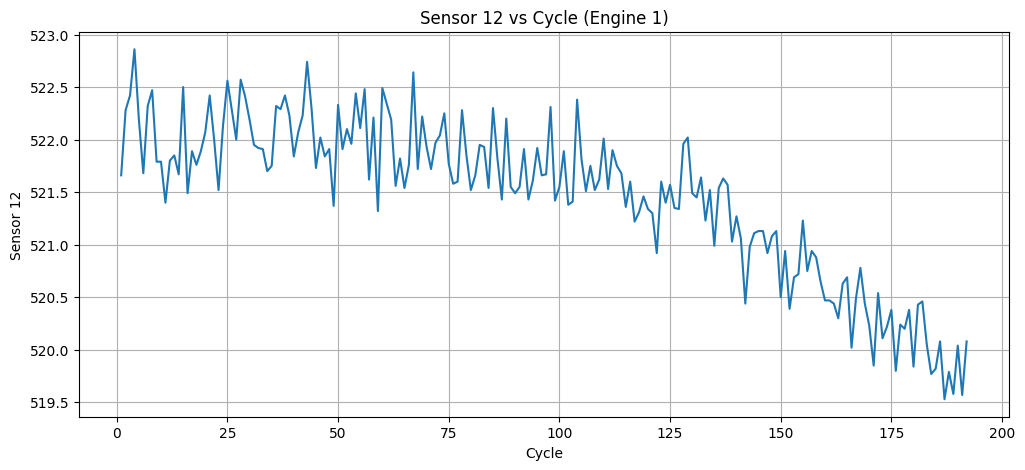

In [25]:
#see how sensor values change as engines age
engine_1 = train_df[train_df["engine_id"] == 1]

plt.figure(figsize=(12,5))
plt.plot(engine_1["cycle"], engine_1["sensor_12"])

plt.xlabel("Cycle")
plt.ylabel("Sensor 12")
plt.title("Sensor 12 vs Cycle (Engine 1)")
plt.grid(True)

plt.show()

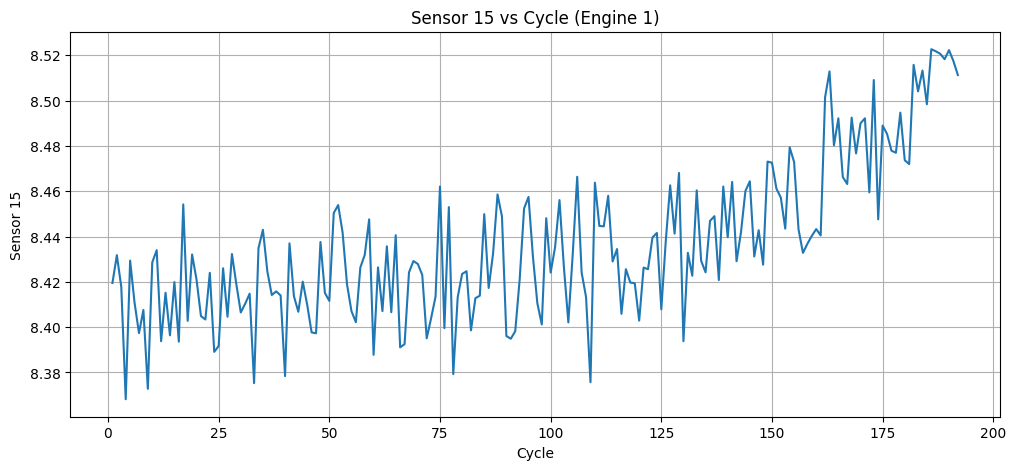

In [26]:
#see how sensor values change as engines age
engine_1 = train_df[train_df["engine_id"] == 1]

plt.figure(figsize=(12,5))
plt.plot(engine_1["cycle"], engine_1["sensor_15"])

plt.xlabel("Cycle")
plt.ylabel("Sensor 15")
plt.title("Sensor 15 vs Cycle (Engine 1)")
plt.grid(True)

plt.show()

In [27]:
#NOTE: As the engine gets older (ie cycles inc) values of some sensors increase while others decrease.
#The model learns these patterns

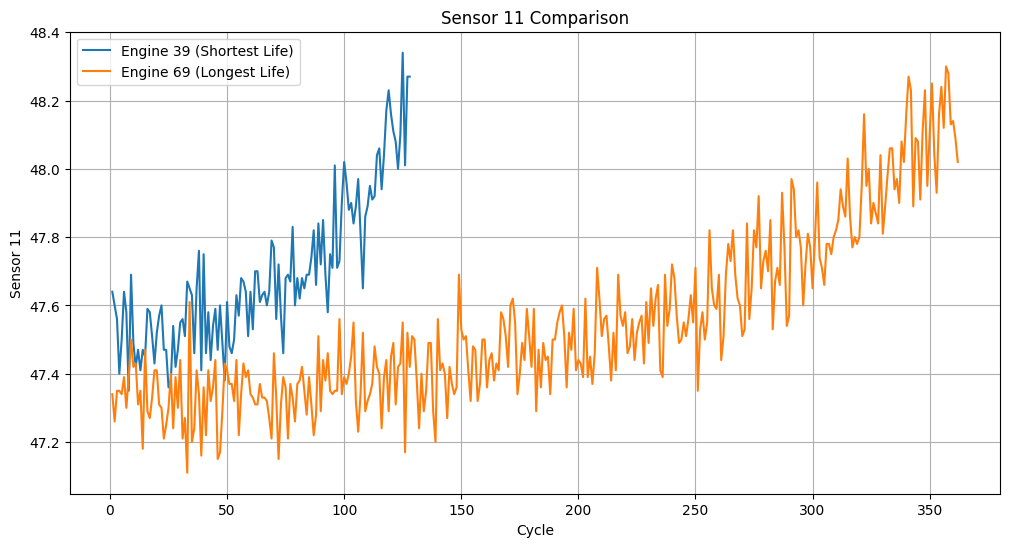

In [28]:
short_engine = train_df[train_df["engine_id"] == 39] #engine 39 since it has shortest engine life
long_engine  = train_df[train_df["engine_id"] == 69] #engine 69 since it has longest engine life
#sensor 11 since it shows a clear degradation trend 
plt.figure(figsize=(12,6))

plt.plot(
    short_engine["cycle"],
    short_engine["sensor_11"],
    label="Engine 39 (Shortest Life)"
)

plt.plot(
    long_engine["cycle"],
    long_engine["sensor_11"],
    label="Engine 69 (Longest Life)"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
#observation
'''
Engine 39:
Degrades quickly
Dies young

Engine 69:
Degrades slowly
Lives longer
'''

'\nEngine 39:\nDegrades quickly\nDies young\n\nEngine 69:\nDegrades slowly\nLives longer\n'

In [31]:
#Create a working dataframe
df = train_df.copy()

In [32]:
max_cycles = df.groupby("engine_id")["cycle"].max()  #RUL = Remaining Useful Life

df["RUL"] = (
    df["engine_id"].map(max_cycles)
    - df["cycle"]
)

In [33]:
df[["engine_id", "cycle", "RUL"]].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [34]:
#Correlation with RUL
correlation = df.corr(numeric_only=True)["RUL"]

correlation.sort_values()

cycle          -0.736241
sensor_11      -0.696228
sensor_4       -0.678948
sensor_15      -0.642667
sensor_2       -0.606484
sensor_17      -0.606154
sensor_3       -0.584520
sensor_8       -0.563968
sensor_13      -0.562569
sensor_9       -0.390102
sensor_14      -0.306769
sensor_6       -0.128348
op_setting_1   -0.003198
op_setting_2   -0.001948
engine_id       0.078753
sensor_20       0.629428
sensor_21       0.635662
sensor_7        0.657223
sensor_12       0.671983
RUL             1.000000
op_setting_3         NaN
sensor_1             NaN
sensor_5             NaN
sensor_10            NaN
sensor_16            NaN
sensor_18            NaN
sensor_19            NaN
Name: RUL, dtype: float64

In [35]:
correlation.sort_values().head(10)

cycle       -0.736241
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
Name: RUL, dtype: float64

In [36]:
correlation.sort_values().tail(10)

sensor_7        0.657223
sensor_12       0.671983
RUL             1.000000
op_setting_3         NaN
sensor_1             NaN
sensor_5             NaN
sensor_10            NaN
sensor_16            NaN
sensor_18            NaN
sensor_19            NaN
Name: RUL, dtype: float64

In [39]:
#NOTE: sensor11= 0.69, As engine ages: Cycle ↑, Sensor 11 ↑, RUL ↓. Therefore: Sensor 11 ↑ RUL ↓ implies: Negative correlation.

In [3]:
'''
Observation:
Top degradation sensors appear to be negative(Sensors whose readings change the most consistently as the engine degrades)
sensor_11  -0.69
sensor_4   -0.68
sensor_15  -0.64
sensor_2   -0.61
sensor_17  -0.61
These increase as failure approaches.
'''

'\nObservation:\nTop degradation sensors appear to be negative(Sensors whose readings change the most consistently as the engine degrades)\nsensor_11  -0.69\nsensor_4   -0.68\nsensor_15  -0.64\nsensor_2   -0.61\nsensor_17  -0.61\nThese increase as failure approaches.\n'

In [42]:
'''
Also another obs,
op_setting_1  -0.003
op_setting_2  -0.001
means operating settings have almost no relationship with degradation in FD001.
'''

'\nAlso another obs,\nop_setting_1  -0.003\nop_setting_2  -0.001\nmeans operating settings have almost no relationship with degradation in FD001.\n'

In [46]:
#Also NaN values indicate that the sensor values are constant, since these sensor values never change correlation can't be calculated
#ie for sensor_1 sensor_5 sensor_10 sensor_16 sensor_18 sensor_19

In [5]:
#Finding: Strong candidates for predicting engine degradation,health status and RUL:
#sensor_11 sensor_4 sensor_15 sensor_2 sensor_17 sensor_12 sensor_7 sensor_21 sensor_20
#These sensors show strong relationships with engine health and are likely to contain useful degradation information.

In [49]:
#Correlation only capture linear relationship but engines often degrade non-linearly

In [51]:
#Create classification labels
df["health_status"] = pd.cut(
    df["RUL"],
    bins=[-1, 30, 100, float("inf")],
    labels=["Critical", "Warning", "Healthy"]
)

In [52]:
df["health_status"].value_counts()

health_status
Healthy     10531
Warning      7000
Critical     3100
Name: count, dtype: int64

In [53]:
df["health_status"].value_counts(normalize=True) * 100

health_status
Healthy     51.044545
Warning     33.929524
Critical    15.025932
Name: proportion, dtype: float64

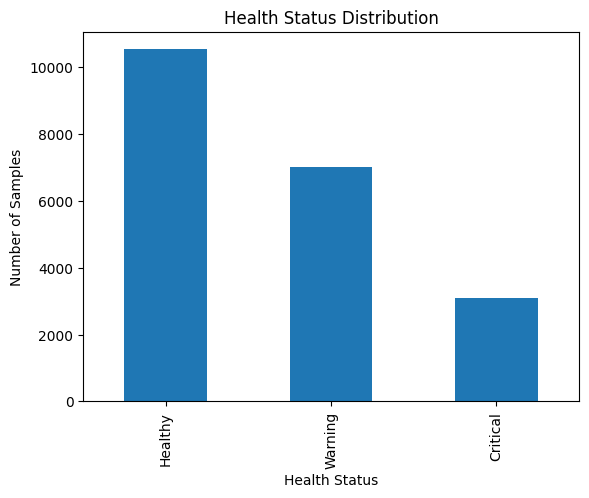

In [54]:
#Visualize class distribution
import matplotlib.pyplot as plt

df["health_status"].value_counts().plot(
    kind="bar"
)

plt.title("Health Status Distribution")
plt.xlabel("Health Status")
plt.ylabel("Number of Samples")

plt.show()

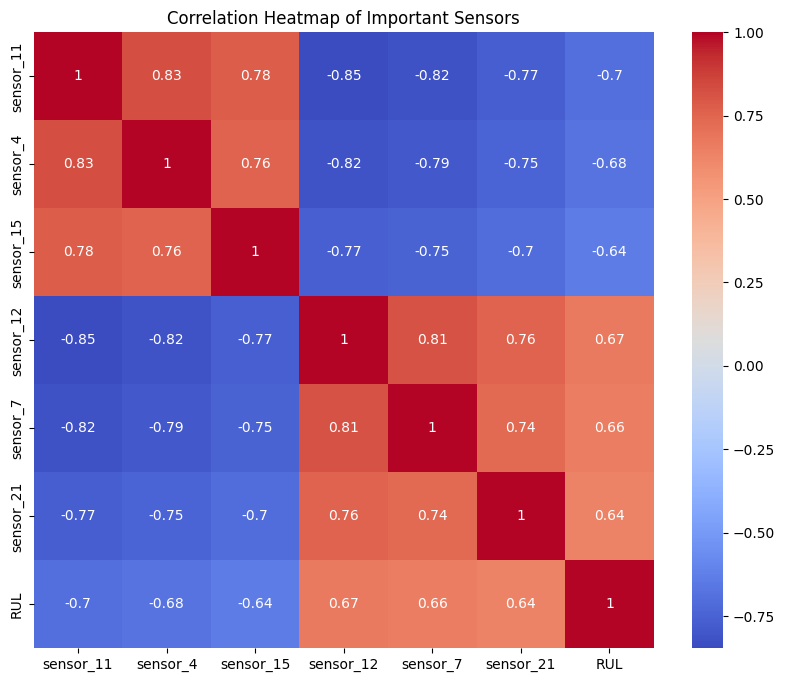

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = [
    "sensor_11",
    "sensor_4",
    "sensor_15",
    "sensor_12",
    "sensor_7",
    "sensor_21",
    "RUL"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Important Sensors")

plt.show()